<a href="https://colab.research.google.com/github/mcsjnn/Acuario-poo/blob/main/Laboratorio03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Producto,Categoria,Vendedor,Region,Unidades,Precio_Unitario,Total_Venta
ID_Venta,,,,,,,
V001,Camiseta,Ropa casual,Juan Perez,Norte,15,12,180
V002,Pantalon,Ropa formal,Ana Torres,Sur,8,25,200
V003,Blusa,Ropa casual,Luis Gomez,Este,20,18,360
V004,Vestido,Ropa femenina,Maria Ruiz,Oeste,12,30,360
V005,Camisa,Ropa formal,Pedro Mendez,Norte,10,22,220


In [2]:
# Asegúrate de que el nombre coincida exactamente con el archivo que subiste
df = pd.read_csv("ventas_textiles.csv", index_col=0)

# Mostrar las primeras filas
df.head()


,Producto,Categoria,Vendedor,Region,Unidades,Precio_Unitario,Total_Venta
ID_Venta,,,,,,,
V001,Camiseta,Ropa casual,Juan Perez,Norte,15,12,180
V002,Pantalon,Ropa formal,Ana Torres,Sur,8,25,200
V003,Blusa,Ropa casual,Luis Gomez,Este,20,18,360
V004,Vestido,Ropa femenina,Maria Ruiz,Oeste,12,30,360
V005,Camisa,Ropa formal,Pedro Mendez,Norte,10,22,220


In [3]:
df.shape

(30, 7)

In [4]:
df.head(15)

,Producto,Categoria,Vendedor,Region,Unidades,Precio_Unitario,Total_Venta
ID_Venta,,,,,,,
V001,Camiseta,Ropa casual,Juan Perez,Norte,15,12,180
V002,Pantalon,Ropa formal,Ana Torres,Sur,8,25,200
V003,Blusa,Ropa casual,Luis Gomez,Este,20,18,360
V004,Vestido,Ropa femenina,Maria Ruiz,Oeste,12,30,360
V005,Camisa,Ropa formal,Pedro Mendez,Norte,10,22,220
V006,Sudadera,Ropa deportiva,Carla Diaz,Sur,6,28,168
V007,Short,Ropa casual,Juan Perez,Este,18,15,270
V008,Falda,Ropa femenina,Ana Torres,Oeste,14,20,280
V009,Leggings,Ropa deportiva,Luis Gomez,Norte,9,17,153


In [6]:
df_sorted = df.sort_values(by="Total_Venta", ascending=False)
df_sorted.head(15)   # mostramos los 15 primeros ya ordenados

,Producto,Categoria,Vendedor,Region,Unidades,Precio_Unitario,Total_Venta
ID_Venta,,,,,,,
V022,Jeans,Ropa casual,Maria Ruiz,Sur,17,26,442
V027,Camisa,Ropa formal,Luis Gomez,Este,20,22,440
V004,Vestido,Ropa femenina,Maria Ruiz,Oeste,12,30,360
V030,Falda,Ropa femenina,Carla Diaz,Sur,18,20,360
V003,Blusa,Ropa casual,Luis Gomez,Este,20,18,360
V016,Camisa,Ropa formal,Maria Ruiz,Oeste,16,22,352
V014,Blusa,Ropa casual,Ana Torres,Sur,19,18,342
V013,Pantalon,Ropa formal,Juan Perez,Norte,13,25,325
V018,Short,Ropa casual,Carla Diaz,Sur,21,15,315


In [7]:
# Revisa primero los nombres de las columnas
print(df.columns.tolist())

# Tendencia central
central = {
    "count": df["Total_Venta"].count(),
    "mean": df["Total_Venta"].mean(),
    "median": df["Total_Venta"].median(),
    "mode": df["Total_Venta"].mode().tolist()  # lista porque puede haber más de una moda
}
pd.DataFrame([central])


['Producto', 'Categoria', 'Vendedor', 'Region', 'Unidades', 'Precio_Unitario', 'Total_Venta']


,count,mean,median,mode
0,30,258.87,238.50,"[180, 360]"


In [8]:
q1 = df["Precio_Unitario"].quantile(0.25)
q3 = df["Precio_Unitario"].quantile(0.75)

dispersion = {
    "min": df["Precio_Unitario"].min(),
    "max": df["Precio_Unitario"].max(),
    "rango": df["Precio_Unitario"].max() - df["Precio_Unitario"].min(),
    "varianza": df["Precio_Unitario"].var(ddof=1),
    "desviacion_std": df["Precio_Unitario"].std(ddof=1),
    "Q1 (25%)": q1,
    "Q3 (75%)": q3,
    "IQR": q3 - q1,
    "coef_variacion": df["Precio_Unitario"].std(ddof=1) / df["Precio_Unitario"].mean()
}
pd.DataFrame([dispersion])


,min,max,rango,varianza,desviacion_std,Q1 (25%),Q3 (75%),IQR,coef_variacion
0,12,45,33,67.29,8.20,17.25,27.50,10.25,0.36


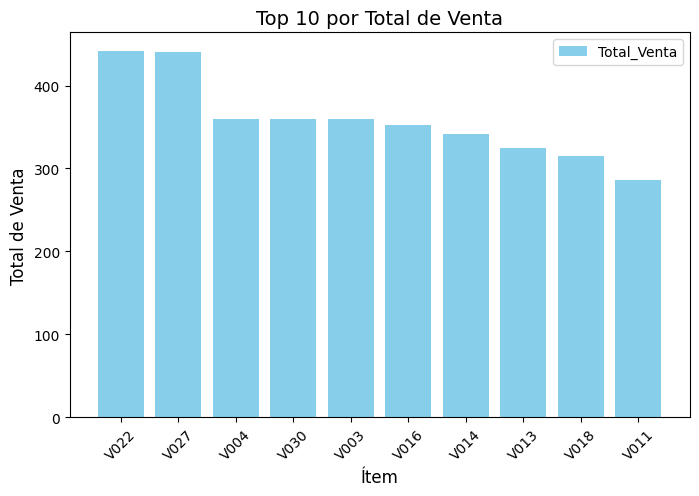

In [10]:
import matplotlib.pyplot as plt

# Ordenar descendente por Total_venta
df_sorted = df.sort_values(by="Total_Venta", ascending=False)

# Gráfico de barras
plt.bar(df_sorted.head(10).index, df_sorted.head(10)["Total_Venta"], color="skyblue")
plt.title("Top 10 por Total de Venta", fontsize=14)
plt.xlabel("Ítem", fontsize=12)
plt.ylabel("Total de Venta", fontsize=12)
plt.legend(["Total_Venta"])
plt.xticks(rotation=45)
plt.show()


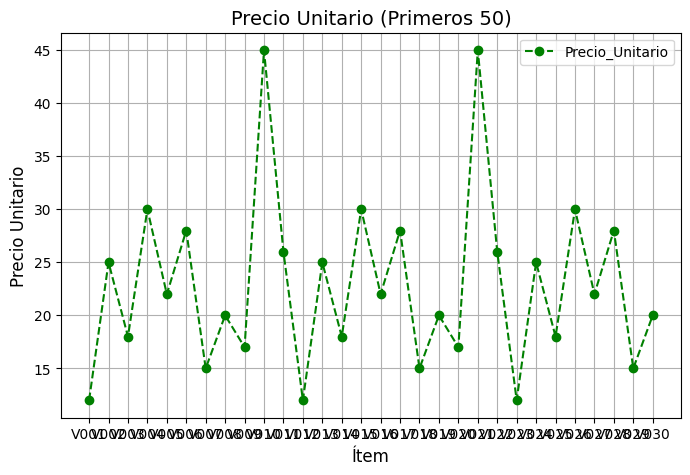

In [13]:
plt.plot(df["Precio_Unitario"].head(50), marker="o", color="green", linestyle="--")
plt.title("Precio Unitario (Primeros 50)", fontsize=14)
plt.xlabel("Ítem", fontsize=12)
plt.ylabel("Precio Unitario", fontsize=12)
plt.legend(["Precio_Unitario"])
plt.grid(True)
plt.show()




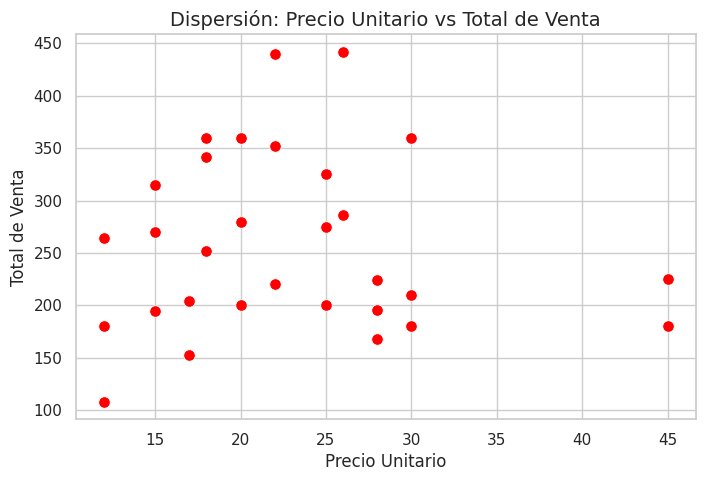

In [14]:
sns.set(style="whitegrid")

ax = sns.scatterplot(data=df, x="Precio_Unitario", y="Total_Venta", color="red", s=70)
ax.set_title("Dispersión: Precio Unitario vs Total de Venta", fontsize=14)
ax.set_xlabel("Precio Unitario", fontsize=12)
ax.set_ylabel("Total de Venta", fontsize=12)
plt.show()


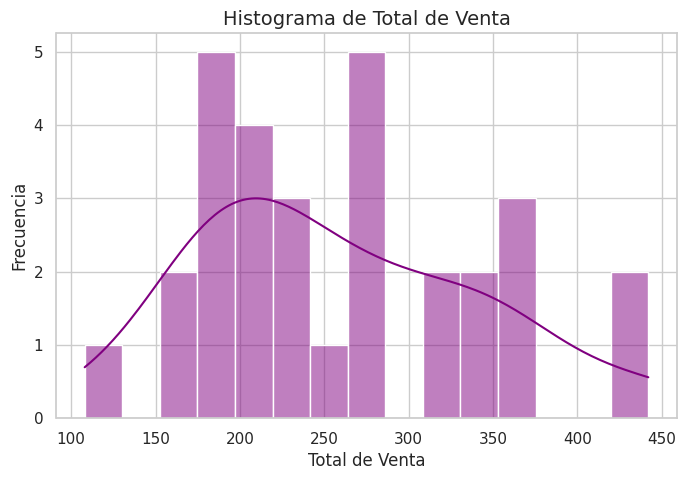

In [15]:
ax = sns.histplot(data=df, x="Total_Venta", bins=15, kde=True, color="purple")
ax.set_title("Histograma de Total de Venta", fontsize=14)
ax.set_xlabel("Total de Venta", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
plt.show()
